# Machine Learning Exercise 5
#### by Thanh Tran, Gero B., Robin-Marcel Hanne

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [60]:
def omp_regression(X, y, T):
    """
    Parameters:
    -----------
    X : ndarray of shape (N, D)
        The feature matrix.
    y : ndarray of shape (N,)
        The target response vector.
    T : int
        The desired number of non-zero elements in the final solution.

    Returns:
    --------
    beta_history : ndarray of shape (D, T)
        A matrix where the t-th column contains the sparse beta coefficients at step t.
    """
    N, D = X.shape


    active_set = []
    inactive_set = list(range(D))
    residual = y.copy()

    beta_history = np.zeros((D, T))
    for t in range(1, T + 1):

        correlations = [np.abs(np.dot(X[:, j], residual)) if j in inactive_set else -1 for j in range(D)]
        j_t = np.argmax(correlations)

        active_set.append(j_t)
        inactive_set.remove(j_t)
        X_t = X[:, active_set]


        beta_active = np.linalg.lstsq(X_t, y, rcond=None)[0]

        residual = y - np.dot(X_t, beta_active)

        for idx, feature_idx in enumerate(active_set):
            beta_history[feature_idx, t - 1] = beta_active[idx]

    return beta_history

In [61]:
def predict_mse_lda(X, beta, intercept):
    scores = X @ beta + intercept
    return np.where(scores >= 0, 1, -1)

In [62]:
def train_mse_lda(X, y):
    """
    Trains the linear classifier based on the MSE formulation.
    """
    X_pos = X[y == 1]   # Digit 9
    X_neg = X[y == -1]  # Digit 3

    mu_1 = np.mean(X_pos, axis=0)
    mu_neg1 = np.mean(X_neg, axis=0)

    X_pos_centered = X_pos - mu_1
    X_neg_centered = X_neg - mu_neg1

    N = len(y)
    Sigma = (X_pos_centered.T @ X_pos_centered + X_neg_centered.T @ X_neg_centered) / N

    mean_diff = mu_1 - mu_neg1
    beta = np.linalg.solve(Sigma, mean_diff)

    intercept = -0.5 * (mu_1 + mu_neg1) @ beta

    return beta, intercept

#### Applying it to the extracted features

##### Imported from Exercise 1


In [63]:
digits = load_digits()
X_all, y_all = digits.data, digits.target

# Filter for classes 3 and 9
mask = (y_all == 3) | (y_all == 9)
X_filtered = X_all[mask]
y_filtered = y_all[mask]

y_lda = np.where(y_filtered == 3, 1, -1)

# Split into train and test sets (stratified to ensure balanced classes)
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_lda, test_size=0.3, random_state=42, stratify=y_lda
)

##### Decision regions

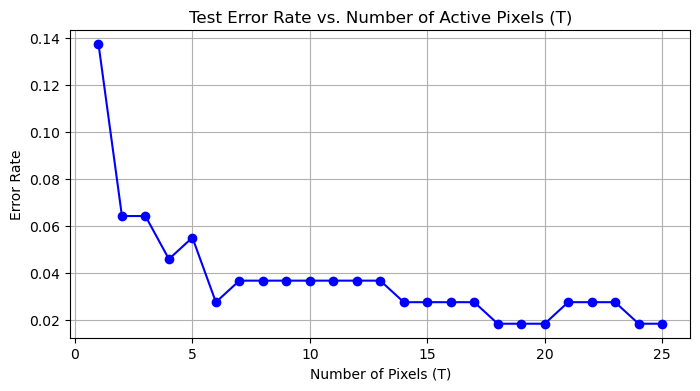

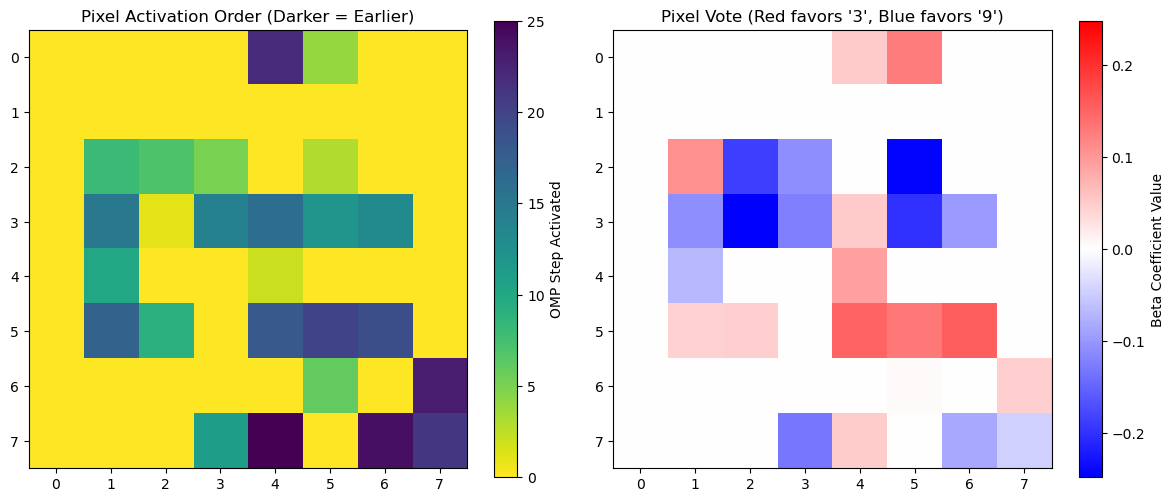

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# OMP Regression
T_max = 25  # up to 25 pixels
beta_history = omp_regression(X_train_scaled, y_train, T=T_max)

test_errors = []
for t in range(T_max):
    beta_t = beta_history[:, t]
    predictions = np.sign(np.dot(X_test_scaled, beta_t))
    predictions[predictions == 0] = -1

    error_rate = np.mean(predictions != y_test)
    test_errors.append(error_rate)

plt.figure(figsize=(8, 4))
plt.plot(range(1, T_max + 1), test_errors, marker='o', color='b', linestyle='-')
plt.title("Test Error Rate vs. Number of Active Pixels (T)")
plt.xlabel("Number of Pixels (T)")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()

# To visualize we use two thing: Activation order (which we track by seeing which coefficents become non-zero first)
activation_order = np.zeros(64)
# Use the final step coefficients to see class votes (Positive favors '3', Negative favors '9')
final_coefficients = beta_history[:, -1]

step_activated = 1
for t in range(T_max):
    # Find which feature was added at step t
    active_features = np.where(beta_history[:, t] != 0)[0]
    for f in active_features:
        if activation_order[f] == 0:
            activation_order[f] = step_activated
            step_activated += 1

# Reshape to 8x8
activation_img = activation_order.reshape((8, 8))
votes_img = final_coefficients.reshape((8, 8))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Activation Order
im1 = axes[0].imshow(activation_img, cmap='viridis_r', interpolation='nearest')
axes[0].set_title("Pixel Activation Order (Darker = Earlier)")
fig.colorbar(im1, ax=axes[0], label='OMP Step Activated')

# Plot Class Voting Map
im2 = axes[1].imshow(votes_img, cmap='bwr', vmin=-np.max(np.abs(votes_img)), vmax=np.max(np.abs(votes_img)))
axes[1].set_title("Pixel Vote (Red favors '3', Blue favors '9')")
fig.colorbar(im2, ax=axes[1], label='Beta Coefficient Value')

plt.tight_layout()
plt.show()

#####  How many pixels should be used for acceptable error rates? Is it necessary/beneficial to standardize the data before training and testing?

Yes, it is beneficial. The step 1 of the OMP relies on the dot product which can cause scaling issues if not standardized.

The plot above suggests that by using 6 or 7 pixels the error rate already droppoed significantly. After 14+ pixels it plateus and only varies slightly between a small range.

## Feature Comparison

The OMP regression seems to have picked features that differ from our previous feature classifier.
Our previous classification was based on ring and centre features in order to differentiate between the 3 and 9.
Whilst it seems as if the AI chose a pattern that nears a little a circle for the 9 but excluded the the top and bottom of the circle, the majority of the activation pixels seem rather different from ours.